In [1]:
import pandas as pd
import numpy as np

# cleaning

In [ ]:
df = pd.read_excel("DATA 2023-2026.xlsx")
df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")

num_cols = [
    "volumen_surtido",
    "ciclo_(tiempo)",
    "hora",
    "mes",
    "dia",
    "año",
    "remision",
    "numero_de_pedido",
    "numero_de_camion",
    "numero_de_planta",
]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

for c in ["nombre_del_proyecto", "material", "cliente"]:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip()

df = df.rename(
    columns={
        "dia": "dia_de_semana",
        "hora_de_asignacion/carga": "hora_de_carga",
        "ciclo_(tiempo)": "ciclo",
    }
)

df["dia"] = df["fecha_del_pedido"].dt.day.astype("int64")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 78589 entries, 0 to 78588
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   año                       78589 non-null  int64         
 1   remision                  78589 non-null  int64         
 2   fecha_del_pedido          78589 non-null  datetime64[us]
 3   numero_de_pedido          78589 non-null  int64         
 4   hora_comprometida         78589 non-null  datetime64[us]
 5   numero_de_camion          78589 non-null  int64         
 6   numero_de_planta          78589 non-null  int64         
 7   volumen_surtido           78589 non-null  float64       
 8   hora_de_asignacion/carga  78589 non-null  datetime64[us]
 9   hora_de_regreso           78589 non-null  datetime64[us]
 10  ciclo_(tiempo)            78589 non-null  int64         
 11  cliente                   78456 non-null  str           
 12  nombre_del_proyecto       785

In [ ]:
mask = (
    (df["numero_de_planta"] == 512)
    & (df["volumen_surtido"] >= 0.5)
    & (df["volumen_surtido"] <= 7.5)
    & (df["ciclo"] >= 50)
    & (df["ciclo"] <= 110)
)

df = df.loc[mask].copy()

In [ ]:
critical = [
    "año",
    "mes",
    "dia",
    "numero_de_camion",
    "hora_de_carga",
    "hora_comprometida",
    "ciclo",
]
df = df.dropna(subset=[c for c in critical if c in df.columns]).copy()

In [13]:
df = df[
    df["mes"].between(1, 12, inclusive="both")
    & df["dia"].between(1, 31, inclusive="both")
    & df["año"].between(2000, 2100, inclusive="both")
    & df["dia_de_semana"].between(1, 7, inclusive="both")
].copy()

In [ ]:
df["retraso_de_pedido"] = (
    df["hora_de_carga"] - df["hora_comprometida"]
).dt.total_seconds() / 60

In [ ]:
q99 = df["ciclo"].quantile(0.99)
df = df[df["ciclo"] <= q99].copy()

truck_counts = df["numero_de_camion"].value_counts(dropna=True)
valid_trucks = truck_counts[truck_counts > 20].index
df = df[df["numero_de_camion"].isin(valid_trucks)].copy()

In [17]:
df["instancia_de_orden"] = (
    df["numero_de_pedido"].astype("Int64").astype(str)
    + "_"
    + df["año"].astype("Int64").astype(str)
    + "-"
    + df["mes"].astype("Int64").astype(str).str.zfill(2)
    + "-"
    + df["dia"].astype("Int64").astype(str).str.zfill(2)
)

In [ ]:
df = df.sort_values(["numero_de_camion", "hora_de_carga"]).copy()

mask_delay_ok = df["retraso_de_pedido"].abs() <= 360

end_time = df["hora_de_carga"] + pd.to_timedelta(df["ciclo"], unit="m")
next_start = df.groupby("numero_de_camion")["hora_de_carga"].shift(-1)

mask_no_overlap = (next_start.isna()) | (end_time <= next_start)

df = df[mask_delay_ok & mask_no_overlap].copy()

df.reset_index(drop=True, inplace=True)

# visualizations

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

df["dispatch_hour"] = df["dispatch_dt"].dt.hour
df["dispatch_date"] = df["dispatch_dt"].dt.date
df["dow"] = df["dispatch_dt"].dt.day_name()

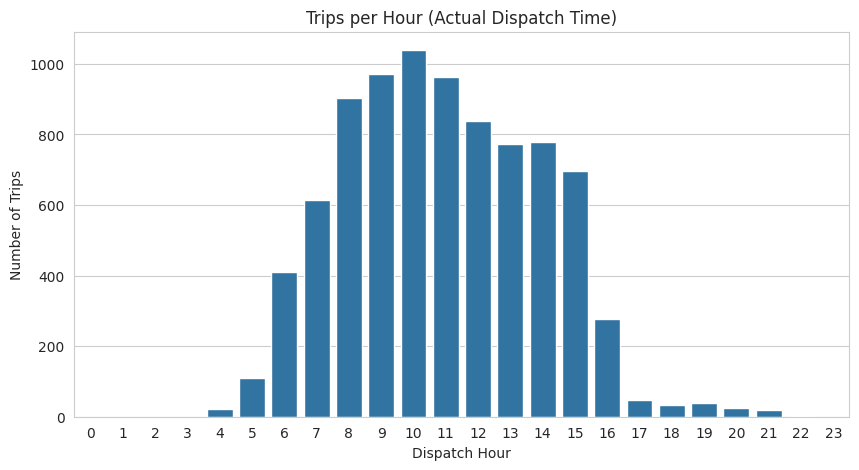

In [63]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="dispatch_hour", order=range(24))
plt.title("Trips per Hour (Actual Dispatch Time)")
plt.xlabel("Dispatch Hour")
plt.ylabel("Number of Trips")
plt.show()

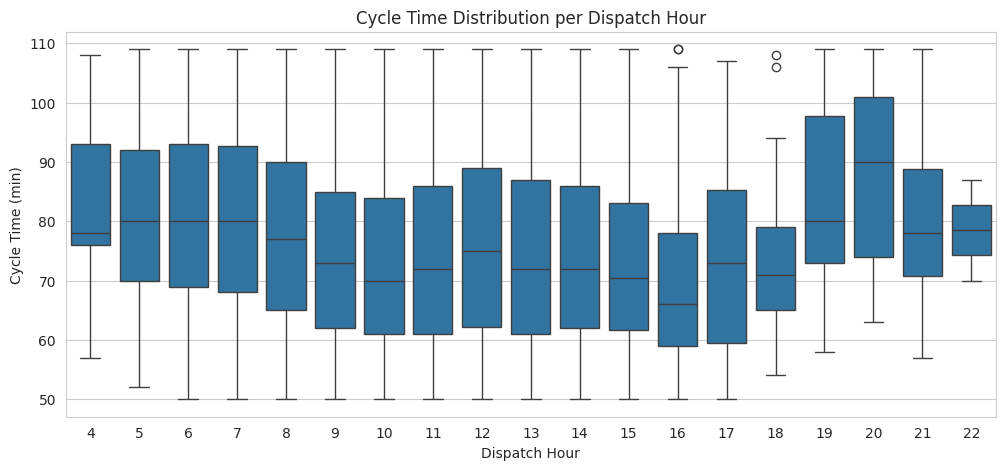

In [64]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x="dispatch_hour", y="u_cicle")
plt.title("Cycle Time Distribution per Dispatch Hour")
plt.xlabel("Dispatch Hour")
plt.ylabel("Cycle Time (min)")
plt.show()

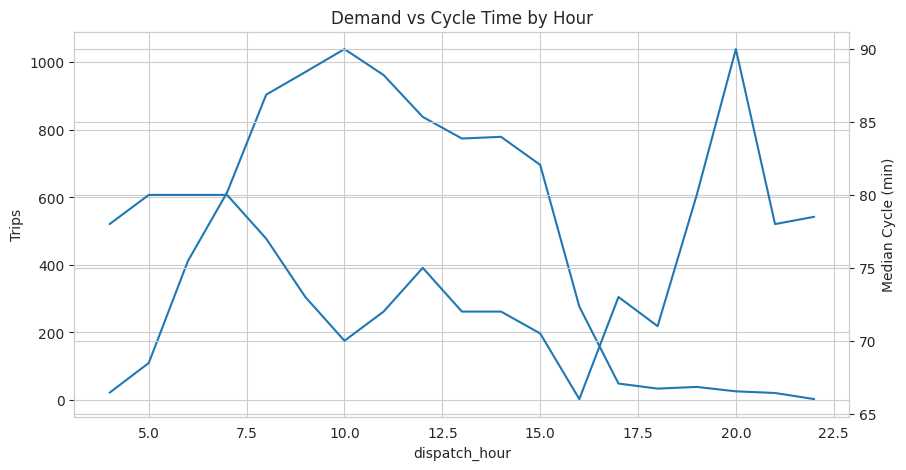

In [65]:
hour_stats = (
    df.groupby("dispatch_hour")
    .agg(trips=("u_cicle", "size"), median_cycle=("u_cicle", "median"))
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(10, 5))

sns.lineplot(data=hour_stats, x="dispatch_hour", y="trips", ax=ax1)
ax1.set_ylabel("Trips")

ax2 = ax1.twinx()
sns.lineplot(data=hour_stats, x="dispatch_hour", y="median_cycle", ax=ax2)
ax2.set_ylabel("Median Cycle (min)")

plt.title("Demand vs Cycle Time by Hour")
plt.show()

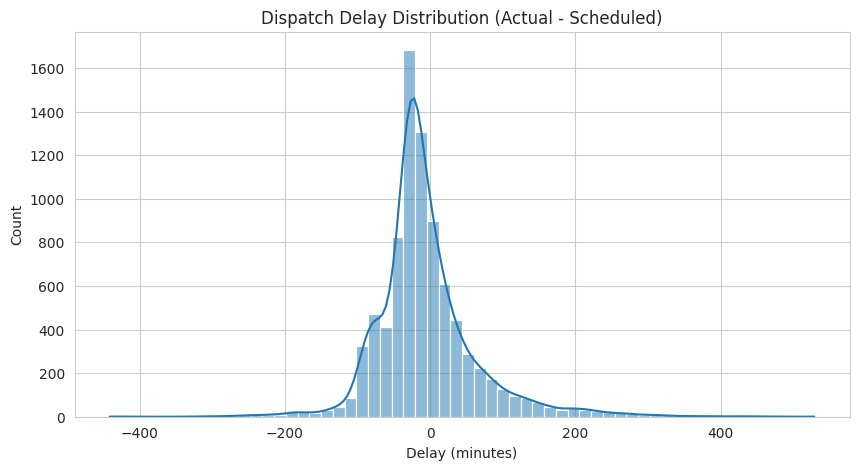

In [66]:
plt.figure(figsize=(10, 5))
sns.histplot(df["dispatch_delay_min"], bins=60, kde=True)
plt.title("Dispatch Delay Distribution (Actual - Scheduled)")
plt.xlabel("Delay (minutes)")
plt.show()

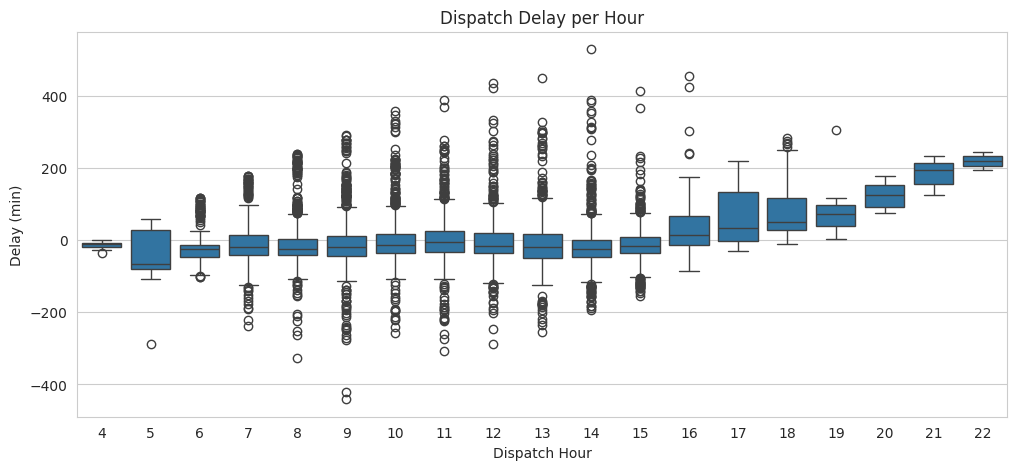

In [67]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x="dispatch_hour", y="dispatch_delay_min")
plt.title("Dispatch Delay per Hour")
plt.xlabel("Dispatch Hour")
plt.ylabel("Delay (min)")
plt.show()

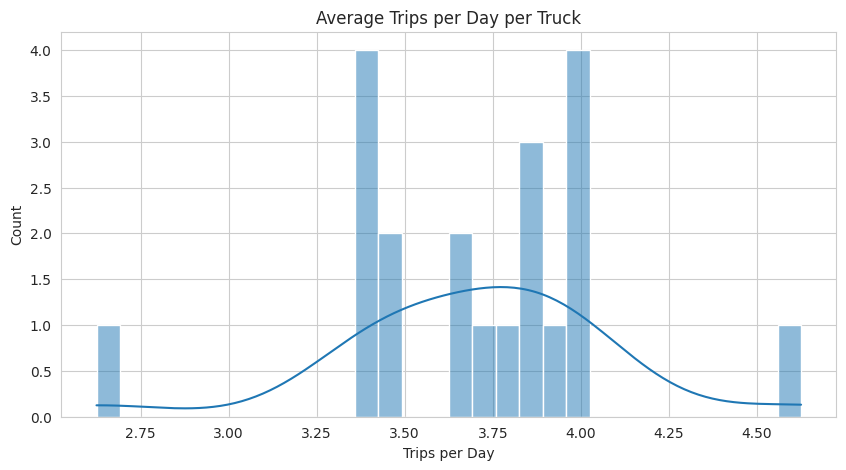

In [68]:
trips_truck_day = (
    df.groupby(["truck_code", "dispatch_date"]).size().reset_index(name="trips")
)

avg_trips = trips_truck_day.groupby("truck_code")["trips"].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.histplot(avg_trips["trips"], bins=30, kde=True)
plt.title("Average Trips per Day per Truck")
plt.xlabel("Trips per Day")
plt.show()

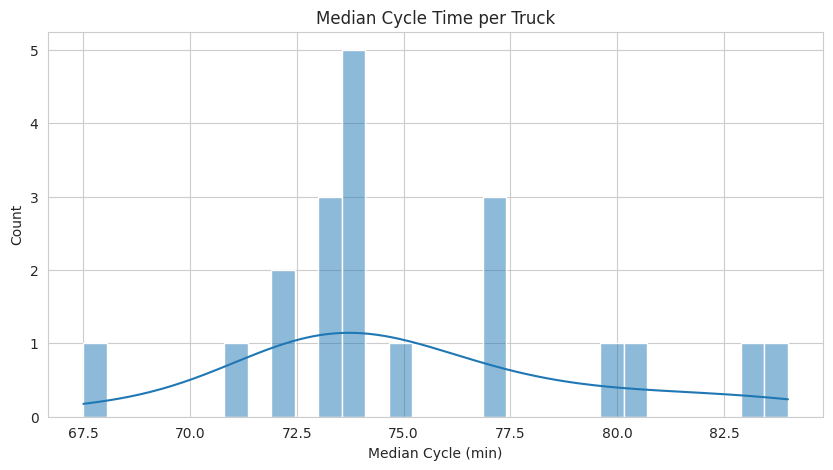

In [69]:
truck_cycle = df.groupby("truck_code")["u_cicle"].median().reset_index()

plt.figure(figsize=(10, 5))
sns.histplot(truck_cycle["u_cicle"], bins=30, kde=True)
plt.title("Median Cycle Time per Truck")
plt.xlabel("Median Cycle (min)")
plt.show()

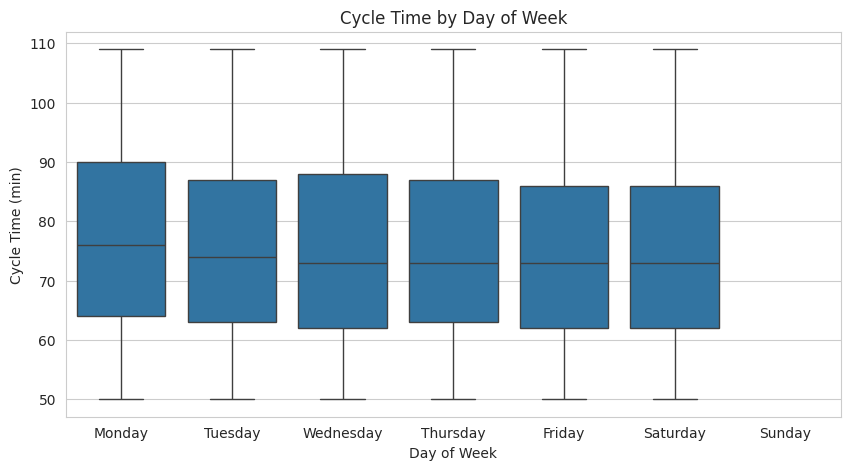

In [70]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x="dow",
    y="u_cicle",
    order=[
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday",
    ],
)
plt.title("Cycle Time by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Cycle Time (min)")
plt.show()

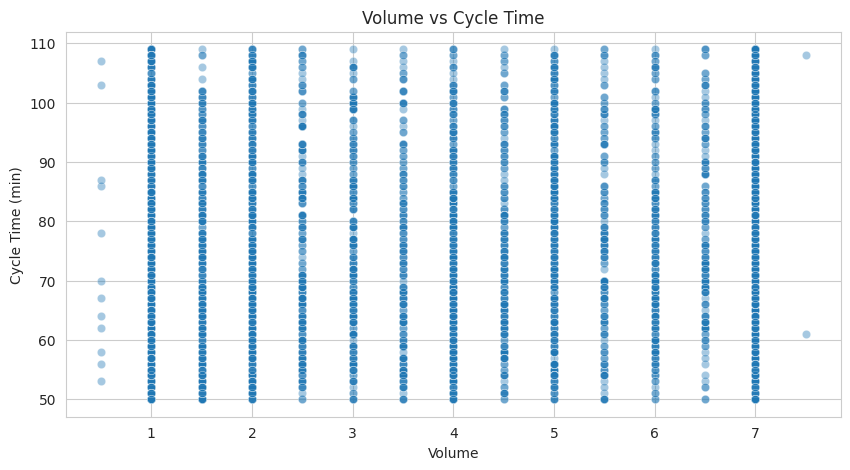

In [71]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df.sample(5000), x="u_volumen", y="u_cicle", alpha=0.4)
plt.title("Volume vs Cycle Time")
plt.xlabel("Volume")
plt.ylabel("Cycle Time (min)")
plt.show()

In [ ]:
df.to_csv("cleaned_data.csv", index=False)